In [51]:
# Core libraries
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Simple logging setup
logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

logger.info("Notebook initialized successfully")

INFO - Notebook initialized successfully


---

## 0. Data Scraping

Scape the data from https://store.steampowered.com/appreviews/ and store them in a csv file.

In [52]:
import requests
import pandas as pd
import time
from pathlib import Path
from typing import List, Dict, Optional
import logging

In [53]:
def scrape_steam_reviews(app_id: int, max_reviews: int = 50000, language: str = 'english', reviews_per_page: int = 100) -> List[Dict]:
    all_reviews = []
    cursor = '*'
    start_time = time.time()
    
    logging.info(f"Starting fetching reviews for app_id={app_id}...")
    
    while len(all_reviews) < max_reviews:
        url = f'https://store.steampowered.com/appreviews/{app_id}'
        params = {
            'json': 1,
            'language': language,
            'cursor': cursor,
            'num_per_page': reviews_per_page,
            'filter': 'recent'
        }
        
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            
            if not data.get('reviews'):
                logging.warning("No more reviews available")
                break
            
            all_reviews.extend(data['reviews'])
            cursor = data.get('cursor')
            
            if not cursor:
                logging.warning("No cursor returned, ending pagination")
                break
            
            time.sleep(1)
            
        except requests.exceptions.RequestException as e:
            logging.error(f"Request failed: {e}")
            time.sleep(10)
            continue
    
    final_reviews = all_reviews[:max_reviews]
    elapsed_time = time.time() - start_time
    
    logging.info(f"Fetched {len(final_reviews)} reviews in {elapsed_time:.2f} seconds")
    
    return final_reviews

In [54]:
def fetch_game_details(app_id: int) -> Dict:
    url = f'https://store.steampowered.com/api/appdetails'
    params = {'appids': app_id}
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if str(app_id) in data and data[str(app_id)]['success']:
            game_data = data[str(app_id)]['data']
            logging.info(f"Fetched game details for '{game_data.get('name', 'Unknown')}'")
            return game_data
        else:
            logging.warning(f"Failed to fetch game details for app_id={app_id}")
            return {}
            
    except requests.exceptions.RequestException as e:
        logging.error(f"Request failed: {e}")
        return {}


def process_reviews(reviews: List[Dict], game_data: Dict = None) -> pd.DataFrame:
    data = []
    
    for review in reviews:
        author = review.get('author', {})
        
        record = {
            'recommended': review.get('voted_up', False),
            'user_id': author.get('steamid', ''),
            'user_games_owned': author.get('num_games_owned', 0),
            'user_num_reviews': author.get('num_reviews', 0),
            'playtime_at_review_hours': author.get('playtime_at_review', 0) / 60,
            'playtime_total_hours': author.get('playtime_forever', 0) / 60,
            'playtime_recent_hours': author.get('playtime_last_two_weeks', 0) / 60,
            'received_free': review.get('received_for_free', False),
            'steam_purchase': review.get('steam_purchase', True),
            'written_early_access': review.get('written_during_early_access', False),
            'votes_helpful': review.get('votes_up', 0),
            'votes_funny': review.get('votes_funny', 0),
            'weighted_vote_score': review.get('weighted_vote_score', 0.0),
            'comment_count': review.get('comment_count', 0),
            'timestamp_created': review.get('timestamp_created', 0),
            'timestamp_updated': review.get('timestamp_updated', 0),
            'review_text': review.get('review', ''),
            'review_length': len(review.get('review', '')),
            'review_id': review.get('recommendationid', '')
        }
        
        if game_data:
            record.update({
                'game_id': game_data.get('steam_appid', ''),
                'game_name': game_data.get('name', ''),
                'game_price': game_data.get('price_overview', {}).get('final', 0) / 100 if game_data.get('price_overview') else 0,
                'game_is_free': game_data.get('is_free', False),
                'game_genre': ','.join([g['description'] for g in game_data.get('genres', [])]),
                'game_categories': ','.join([c['description'] for c in game_data.get('categories', [])]),
                'game_developer': ','.join(game_data.get('developers', [])),
                'game_publisher': ','.join(game_data.get('publishers', [])),
                'game_description': game_data.get('short_description', ''),
                'game_required_age': game_data.get('required_age', 0),
            })
        
        data.append(record)
    
    df = pd.DataFrame(data)
    
    df['playtime_ratio'] = df['playtime_at_review_hours'] / (df['playtime_total_hours'] + 1)
    df['review_engagement_score'] = df['votes_helpful'] + df['votes_funny'] * 0.5
    df['experienced_gamer'] = df['user_games_owned'] > 50
    df['active_reviewer'] = df['user_num_reviews'] > 5
    
    feature_count = len(df.columns)
    logging.info(f"Processed {len(df)} reviews into DataFrame with {feature_count} features")
    
    return df

In [55]:
# # SINGLE GAME SCRAPING (COMMENTED OUT)
# APP_ID = 578080  # PUBG
# MAX_REVIEWS = 50000
# OUTPUT_FILE = 'steam_reviews.csv'
# 
# logging.info(f"Fetching game metadata for app_id={APP_ID}...")
# game_data = fetch_game_details(APP_ID)
# 
# logging.info(f"Starting to scrape reviews for app_id={APP_ID}...")
# reviews = scrape_steam_reviews(app_id=APP_ID, max_reviews=MAX_REVIEWS)

# MULTI-GAME SCRAPING
GAMES = [
    236430,    # Dark Souls 2
    1517290,   # Battlefield 2042
    1938090,   # Call of Duty: Vanguard
    1203220,   # Naraka: Bladepoint
    2357570,   # Overwatch 2 (~20% positive - most hated on Steam)
    976730,    # Halo: The Master Chief Collection
    1551360,   # Forspoken
    1294810,   # Redfall (~38% positive - controversial)
    954850,    # Kerbal Space Program 2 (~28% positive - controversial)
    1086940,   # Baldur's Gate 3
]

REVIEWS_PER_GAME = 2500
OUTPUT_FILE = 'steam_reviews_multi.csv'

all_game_dfs = []

for idx, app_id in enumerate(GAMES):
    logging.info(f"Processing game {idx+1}/{len(GAMES)}: {app_id}...")
    
    try:
        game_data = fetch_game_details(app_id)
        time.sleep(2)
        
        reviews = scrape_steam_reviews(app_id=app_id, max_reviews=REVIEWS_PER_GAME)
        
        if len(reviews) > 0:
            df_game = process_reviews(reviews, game_data=game_data)
            all_game_dfs.append(df_game)
            logging.info(f"Successfully collected {len(df_game)} reviews for game {app_id}")
        else:
            logging.warning(f"No reviews collected for game {app_id}")
        
        time.sleep(5)
        
    except Exception as e:
        logging.error(f"Failed to process game {app_id}: {e}")
        continue

if all_game_dfs:
    df = pd.concat(all_game_dfs, ignore_index=True)
    df.to_csv(OUTPUT_FILE, index=False)
    logging.info(f"Total dataset: {len(df)} reviews from {len(all_game_dfs)} games saved to {OUTPUT_FILE}")
else:
    logging.error("No data collected from any games")

INFO - Processing game 1/10: 236430...
INFO - Fetched game details for 'DARK SOULS™ II'
INFO - Starting fetching reviews for app_id=236430...
INFO - Fetched 2500 reviews in 42.20 seconds
INFO - Processed 2500 reviews into DataFrame with 33 features
INFO - Successfully collected 2500 reviews for game 236430
INFO - Processing game 2/10: 1517290...
INFO - Fetched game details for 'Battlefield™ 2042'
INFO - Starting fetching reviews for app_id=1517290...
INFO - Fetched 2500 reviews in 39.55 seconds
INFO - Processed 2500 reviews into DataFrame with 33 features
INFO - Successfully collected 2500 reviews for game 1517290
INFO - Processing game 3/10: 1938090...
INFO - Fetched game details for 'Call of Duty®'
INFO - Starting fetching reviews for app_id=1938090...
INFO - Fetched 2500 reviews in 39.45 seconds
INFO - Processed 2500 reviews into DataFrame with 33 features
INFO - Successfully collected 2500 reviews for game 1938090
INFO - Processing game 4/10: 1203220...
INFO - Fetched game details 

In [56]:
# # SINGLE GAME PROCESSING (COMMENTED OUT)
# df = process_reviews(reviews, game_data=game_data)
# df.to_csv(OUTPUT_FILE, index=False)
# logging.info(f"Dataset saved to {OUTPUT_FILE}")

In [57]:
print(f"Dataset shape: {df.shape}")
print(f"Positive reviews: {df['recommended'].sum()} ({df['recommended'].mean()*100:.1f}%)")
print(f"Number of unique games: {df['game_id'].nunique()}")

print(f"\nGames in dataset:")
for game_id in df['game_id'].unique():
    game_df = df[df['game_id'] == game_id]
    game_name = game_df['game_name'].iloc[0]
    pos_pct = game_df['recommended'].mean() * 100
    print(f"  {game_name}: {len(game_df)} reviews ({pos_pct:.1f}% positive)")

print(f"\nFirst few rows:")
df.head()

Dataset shape: (21752, 33)
Positive reviews: 13985 (64.3%)
Number of unique games: 10

Games in dataset:
  DARK SOULS™ II: 2500 reviews (82.8% positive)
  Battlefield™ 2042: 2500 reviews (47.7% positive)
  Call of Duty®: 2500 reviews (43.6% positive)
  NARAKA: BLADEPOINT: 2500 reviews (80.7% positive)
  Overwatch® 2: 123 reviews (44.7% positive)
  Halo: The Master Chief Collection: 2500 reviews (83.1% positive)
  Forza Horizon 5: 2500 reviews (87.2% positive)
  Redfall: 1629 reviews (41.4% positive)
  Kerbal Space Program 2: 2500 reviews (9.6% positive)
  Baldur's Gate 3: 2500 reviews (95.7% positive)

First few rows:


,recommended,user_id,user_games_owned,user_num_reviews,playtime_at_review_hours,playtime_total_hours,playtime_recent_hours,received_free,steam_purchase,written_early_access,...,game_genre,game_categories,game_developer,game_publisher,game_description,game_required_age,playtime_ratio,review_engagement_score,experienced_gamer,active_reviewer
0,True,76561198053944201,145,9,0.233333,0.233333,0.000000,False,True,False,...,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",15,0.189189,0.0,True,True
1,True,76561199815144195,0,8,6.700000,9.833333,9.833333,False,True,False,...,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",15,0.618462,0.0,False,True
2,False,76561198004038352,1862,284,199.566667,199.566667,80.533333,False,True,False,...,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",15,0.995014,2.0,True,True
3,False,76561199117526837,222,4,87.583333,87.583333,6.983333,False,True,False,...,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",15,0.988711,0.0,True,False
4,False,76561199226288585,0,3,72.266667,87.850000,60.950000,False,True,False,...,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",15,0.813356,0.0,False,False


---

## 1. Data Loading & Exploration

Load the preprocessed Steam reviews dataset and perform exploratory analysis.

In [4]:
from pathlib import Path


In [ ]:
DATA_FILE = Path('steam_reviews_multi.csv')

if not DATA_FILE.exists():
    logger.error(f"Data file not found: {DATA_FILE}")
    raise FileNotFoundError(f"Data file not found: {DATA_FILE}")

logger.info(f"Loading data from {DATA_FILE}")
df = pd.read_csv(DATA_FILE)
logger.info(f"Loaded {len(df):,} reviews with {df.shape[1]} columns")

print(f"\nDataset shape: {df.shape}")
df.head()

In [ ]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"\nTarget distribution:")
print(f"  Positive reviews: {df['recommended'].sum():,} ({df['recommended'].mean()*100:.2f}%)")
print(f"  Negative reviews: {(~df['recommended']).sum():,} ({(~df['recommended']).mean()*100:.2f}%)")
print("\n" + "="*60)

In [7]:
# Data quality check
print("DATA QUALITY REPORT")
print("="*60)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

DATA QUALITY REPORT

Missing values:
recommended                  0
user_id                      0
user_games_owned             0
user_num_reviews             0
playtime_at_review_hours     0
playtime_total_hours         0
playtime_recent_hours        0
received_free                0
steam_purchase               0
written_early_access         0
votes_helpful                0
votes_funny                  0
weighted_vote_score          0
comment_count                0
timestamp_created            0
timestamp_updated            0
review_text                 90
review_length                0
review_id                    0
game_id                      0
game_name                    0
game_price                   0
game_is_free                 0
game_genre                   0
game_categories              0
game_developer               0
game_publisher               0
game_description             0
game_required_age            0
playtime_ratio               0
review_engagement_score      0
ex

,user_id,user_games_owned,user_num_reviews,playtime_at_review_hours,playtime_total_hours,playtime_recent_hours,votes_helpful,votes_funny,weighted_vote_score,comment_count,timestamp_created,timestamp_updated,review_length,review_id,game_id,game_price,game_required_age,playtime_ratio,review_engagement_score
count,2.270000e+04,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,2.270000e+04,2.270000e+04,22700.000000,2.270000e+04,22700.0,22700.0,22700.0,22700.000000,22700.000000
mean,7.656120e+16,63.317930,9.889427,776.906423,1014.402471,4.111514,1.052159,0.186079,0.503354,0.044714,1.703303e+09,1.704706e+09,99.694934,1.555447e+08,578080.0,0.0,0.0,0.768036,1.145198
std,3.752984e+08,303.814404,49.174921,1287.777803,1597.093465,13.684895,16.009169,2.696296,0.025123,0.487638,2.976462e+07,3.002258e+07,275.386239,2.567061e+07,0.0,0.0,0.0,0.246094,16.818483
min,7.656120e+16,0.000000,1.000000,0.116667,0.150000,0.000000,0.000000,0.000000,0.317252,0.000000,1.656630e+09,1.656630e+09,0.000000,1.179596e+08,578080.0,0.0,0.0,0.000254,0.000000
25%,7.656120e+16,0.000000,1.000000,81.562500,128.987500,0.000000,0.000000,0.000000,0.500000,0.000000,1.676966e+09,1.678327e+09,8.000000,1.332806e+08,578080.0,0.0,0.0,0.641941,0.000000
50%,7.656120e+16,0.000000,3.000000,316.366667,435.208333,0.000000,0.000000,0.000000,0.500000,0.000000,1.702223e+09,1.703773e+09,24.000000,1.533067e+08,578080.0,0.0,0.0,0.861257,0.000000
75%,7.656120e+16,50.000000,8.000000,933.825000,1205.954167,0.000000,0.000000,0.000000,0.500000,0.000000,1.727378e+09,1.729189e+09,80.000000,1.758303e+08,578080.0,0.0,0.0,0.965894,0.000000
max,7.656120e+16,28185.000000,6066.000000,28506.916667,30239.783333,297.600000,1636.000000,145.000000,0.938077,23.000000,1.761706e+09,1.761706e+09,7832.000000,2.078426e+08,578080.0,0.0,0.0,0.999898,1671.500000


---

## 2. Feature Engineering

Prepare features from review text, playtime, and other variables for the binary classifier.

In [8]:
# Feature engineering imports
from textblob import TextBlob


In [ ]:
logger.info("Starting feature engineering")

df['review_text'] = df['review_text'].fillna('')
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

df['log_playtime_at_review'] = np.log1p(df['playtime_at_review_hours'])
df['log_playtime_recent'] = np.log1p(df['playtime_recent_hours'])

df['game_price'] = df['game_price'].fillna(0)
df['game_genre'] = df['game_genre'].fillna('Unknown')
df['game_description'] = df['game_description'].fillna('')

df['game_description_length'] = df['game_description'].apply(lambda x: len(str(x).split()))

features = [
    'recommended',
    'user_games_owned',
    'user_num_reviews',
    'log_playtime_at_review',
    'log_playtime_recent',
    'playtime_ratio',
    'experienced_gamer',
    'active_reviewer',
    'game_price',
    'game_genre',
    'game_description',
    'game_description_length',
    'word_count'
]

df_subset = df[features].copy()

logger.info(f"Feature engineering complete. Shape: {df_subset.shape}")
print(f"\nDataset shape: {df_subset.shape}")
print(f"\nFeatures used: {[f for f in features if f != 'recommended']}")
df_subset.head()

---

## 3. Model Training

Train the binary classifier to predict whether a user will recommend a game.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
def train_classifier(X_train, y_train, model=None):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    
    numeric = ['user_games_owned', 'game_price', 'user_num_reviews', 
               'log_playtime_at_review', 'log_playtime_recent', 'playtime_ratio', 
               'word_count', 'game_description_length']
    categorical = ['game_genre', 'experienced_gamer', 'active_reviewer']
    
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('desc', TfidfVectorizer(max_features=50, stop_words='english'), 'game_description')
    ])
    
    if model is None:
        model = LogisticRegression(random_state=42, max_iter=1000)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    logger.info(f"Training {model.__class__.__name__} on {len(X_train):,} samples")
    pipeline.fit(X_train, y_train)
    logger.info("Training complete")
    
    return pipeline

In [12]:
logger.info("="*60)
logger.info("Starting Model Training Phase")
logger.info("="*60)

# Prepare data once
logger.info("Preparing train-test split")
X = df_subset.drop('recommended', axis=1)  # Exclude target
y = df_subset['recommended']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logger.info(f"Training set: {len(X_train):,} samples")
logger.info(f"Test set: {len(X_test):,} samples")
logger.info(f"Class distribution (train): Positive={y_train.sum():,} ({y_train.mean()*100:.2f}%), Negative={(~y_train).sum():,} ({(~y_train).mean()*100:.2f}%)")

# Train different models (excluding GaussianNB - incompatible with sparse matrices from TF-IDF)
logger.info("Training multiple model variants...")

logger.info("\n1. Training Logistic Regression...")
pipeline_lr = train_classifier(X_train, y_train, 
                               model=LogisticRegression(random_state=42, max_iter=1000))

logger.info("\n2. Training Random Forest...")
pipeline_rf = train_classifier(X_train, y_train,
                               model=RandomForestClassifier(n_estimators=100, random_state=42))

logger.info("\n3. Training XGBoost...")
pipeline_xgb = train_classifier(X_train, y_train,
                                model=XGBClassifier(random_state=42, eval_metric='logloss'))

logger.info("\n4. Training SVM...")
pipeline_svm = train_classifier(X_train, y_train,
                                model=SVC(probability=True, random_state=42))

logger.info("\n5. Training default model...")
pipeline_default = train_classifier(X_train, y_train)

logger.info("="*60)
logger.info("All models trained successfully")
logger.info("="*60)

INFO - ============================================================
INFO - Starting Model Training Phase
INFO - ============================================================
INFO - Preparing train-test split
INFO - Training set: 18,160 samples
INFO - Test set: 4,540 samples
INFO - Class distribution (train): Positive=12,477 (68.71%), Negative=5,683 (31.29%)
INFO - Training multiple model variants...
INFO - 
1. Training Logistic Regression...
INFO - Training LogisticRegression on 18,160 samples
INFO - Training complete
INFO - 
2. Training Random Forest...
INFO - Training RandomForestClassifier on 18,160 samples
INFO - Training complete
INFO - 
3. Training XGBoost...
INFO - Training XGBClassifier on 18,160 samples
INFO - Training complete
INFO - 
4. Training SVM...
INFO - Training SVC on 18,160 samples
INFO - Training complete
INFO - 
5. Training default model...
INFO - Training LogisticRegression on 18,160 samples
INFO - Training complete
INFO - ==========================================

INFO - Comparing 5 models
INFO - Training LogisticRegression on 18,160 samples
INFO - Training complete



Training Logistic Regression...


INFO - Logistic Regression: Accuracy=0.7084, AUC-ROC=0.6976, Time=0.16s
INFO - Training RandomForestClassifier on 18,160 samples


Accuracy: 0.7084
AUC-ROC: 0.6976

Training Random Forest...


INFO - Training complete
INFO - Random Forest: Accuracy=0.7322, AUC-ROC=0.7326, Time=1.46s
INFO - Training XGBClassifier on 18,160 samples


...

Accuracy: 0.7445
AUC-ROC: 0.7469

Training Gradient Boosting...


INFO - Training complete
INFO - Gradient Boosting: Accuracy=0.7542, AUC-ROC=0.7633, Time=1.86s
INFO - Training SVC on 18,160 samples


Accuracy: 0.7542
AUC-ROC: 0.7633

Training SVM...


INFO - Training complete
INFO - SVM: Accuracy=0.7454, AUC-ROC=0.7438, Time=27.62s


Accuracy: 0.7454
AUC-ROC: 0.7438


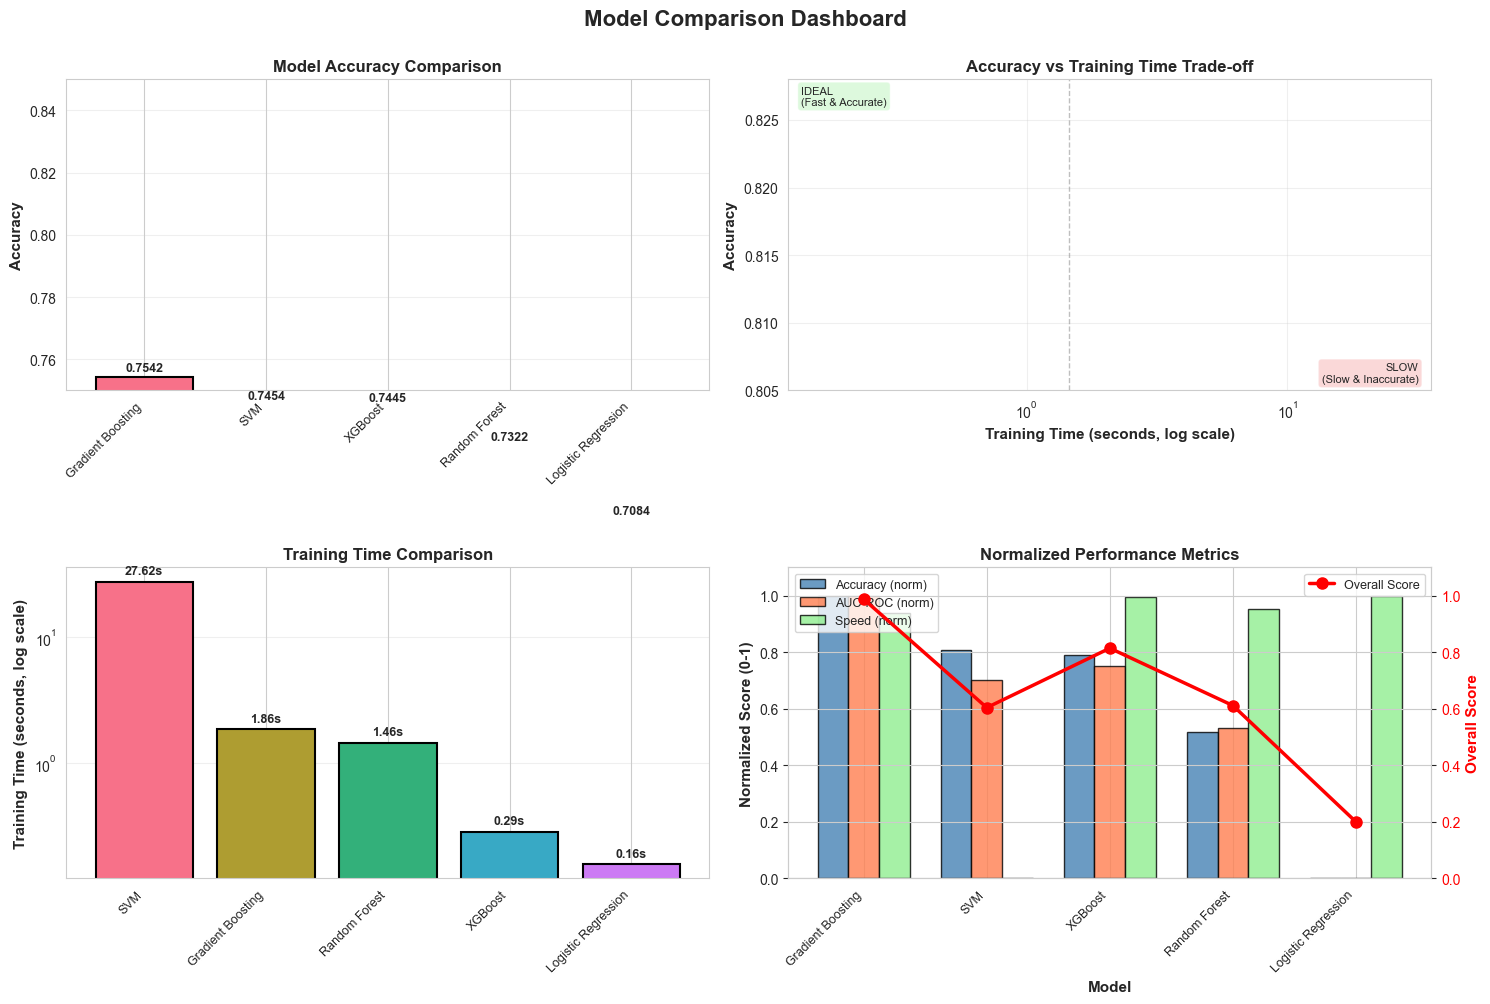

INFO - Best model: Gradient Boosting with accuracy 0.7542



MODEL COMPARISON SUMMARY
              Model  Accuracy  AUC-ROC  Training Time (s)  Overall Score
  Gradient Boosting  0.754185 0.763289           1.859858       0.987601
                SVM  0.745374 0.743755          27.615213       0.604054
            XGBoost  0.744493 0.746861           0.286876       0.814346
      Random Forest  0.732159 0.732634           1.458750       0.611430
Logistic Regression  0.708370 0.697642           0.157682       0.200000

 Best Accuracy: Gradient Boosting (0.7542)
 Best Overall Score: Gradient Boosting (0.9876)


In [13]:
# Define models to compare (excluding GaussianNB - incompatible with sparse matrices)
models_to_test = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

logger.info(f"Comparing {len(models_to_test)} models")

# Compare all models
results = []

for model_name, model in models_to_test.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print('='*60)
    
    # Train
    start_time = time.time()
    pipeline = train_classifier(X_train, y_train, model=model)
    training_time = time.time() - start_time
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    logger.info(f"{model_name}: Accuracy={accuracy:.4f}, AUC-ROC={auc:.4f}, Time={training_time:.2f}s")
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'AUC-ROC': auc,
        'Training Time (s)': training_time
    })
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison Dashboard', fontsize=16, fontweight='bold', y=1.00)

# 1. Accuracy Comparison (vertical bars)
ax1 = axes[0, 0]
colors = sns.color_palette("husl", len(results_df))
bars1 = ax1.bar(range(len(results_df)), results_df['Accuracy'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0.75, 0.85])
ax1.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars1, results_df['Accuracy'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.002, 
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# 2. Accuracy vs Training Time Trade-off (scatter with efficiency frontier)
ax2 = axes[0, 1]
# Create scatter plot
colors_scatter = sns.color_palette("husl", len(results_df))
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax2.scatter(row['Training Time (s)'], row['Accuracy'], 
               s=300, c=[colors_scatter[i]], alpha=0.7, edgecolors='black', linewidth=2)
    ax2.annotate(row['Model'], 
                (row['Training Time (s)'], row['Accuracy']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='black'))

ax2.set_xlabel('Training Time (seconds, log scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy vs Training Time Trade-off', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.805, 0.828])

# Add quadrant lines
median_time = results_df['Training Time (s)'].median()
median_acc = results_df['Accuracy'].median()
ax2.axvline(median_time, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(median_acc, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Annotate quadrants
ax2.text(0.02, 0.98, 'IDEAL\n(Fast & Accurate)', transform=ax2.transAxes, 
         fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax2.text(0.98, 0.02, 'SLOW\n(Slow & Inaccurate)', transform=ax2.transAxes, 
         fontsize=8, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# 3. Training Time Comparison (vertical bars, log scale)
ax3 = axes[1, 0]
results_df_sorted_time = results_df.sort_values('Training Time (s)', ascending=False)
colors_time = sns.color_palette("husl", len(results_df_sorted_time))
bars3 = ax3.bar(range(len(results_df_sorted_time)), results_df_sorted_time['Training Time (s)'], 
                color=colors_time, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Training Time (seconds, log scale)', fontsize=11, fontweight='bold')
ax3.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.set_xticks(range(len(results_df_sorted_time)))
ax3.set_xticklabels(results_df_sorted_time['Model'], rotation=45, ha='right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars3, results_df_sorted_time['Training Time (s)'])):
    ax3.text(bar.get_x() + bar.get_width()/2, val * 1.15, 
             f'{val:.2f}s', ha='center', fontsize=9, fontweight='bold')

# 4. Normalized Performance Metrics
ax4 = axes[1, 1]

# Prepare data for normalized metrics
# Normalize metrics to 0-1 scale
norm_accuracy = (results_df['Accuracy'] - results_df['Accuracy'].min()) / \
                (results_df['Accuracy'].max() - results_df['Accuracy'].min())
norm_auc = (results_df['AUC-ROC'] - results_df['AUC-ROC'].min()) / \
           (results_df['AUC-ROC'].max() - results_df['AUC-ROC'].min())
# For training time, inverse normalization (lower is better)
norm_speed = 1 - ((results_df['Training Time (s)'] - results_df['Training Time (s)'].min()) / \
                  (results_df['Training Time (s)'].max() - results_df['Training Time (s)'].min()))

# Calculate overall score (weighted average)
results_df['Overall Score'] = (norm_accuracy * 0.4 + norm_auc * 0.4 + norm_speed * 0.2)

# Create grouped bar chart for normalized metrics
x = np.arange(len(results_df))
width = 0.25

bars_acc = ax4.bar(x - width, norm_accuracy, width, label='Accuracy (norm)', 
                   color='steelblue', alpha=0.8, edgecolor='black')
bars_auc = ax4.bar(x, norm_auc, width, label='AUC-ROC (norm)', 
                   color='coral', alpha=0.8, edgecolor='black')
bars_speed = ax4.bar(x + width, norm_speed, width, label='Speed (norm)', 
                     color='lightgreen', alpha=0.8, edgecolor='black')

ax4.set_xlabel('Model', fontsize=11, fontweight='bold')
ax4.set_ylabel('Normalized Score (0-1)', fontsize=11, fontweight='bold')
ax4.set_title('Normalized Performance Metrics', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax4.legend(loc='upper left', fontsize=9)
ax4.set_ylim([0, 1.1])
ax4.grid(axis='y', alpha=0.3)

# Add overall score line
ax4_twin = ax4.twinx()
line = ax4_twin.plot(x, results_df['Overall Score'], 'o-', color='red', 
                     linewidth=2.5, markersize=8, label='Overall Score')
ax4_twin.set_ylabel('Overall Score', fontsize=11, fontweight='bold', color='red')
ax4_twin.tick_params(axis='y', labelcolor='red')
ax4_twin.set_ylim([0, 1.1])
ax4_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df[['Model', 'Accuracy', 'AUC-ROC', 'Training Time (s)', 'Overall Score']].to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_overall_idx = results_df['Overall Score'].idxmax()
best_overall_name = results_df.loc[best_overall_idx, 'Model']

print(f"\n Best Accuracy: {best_model_name} ({results_df.iloc[0]['Accuracy']:.4f})")
print(f" Best Overall Score: {best_overall_name} ({results_df.loc[best_overall_idx, 'Overall Score']:.4f})")

logger.info(f"Best model: {best_model_name} with accuracy {results_df.iloc[0]['Accuracy']:.4f}")

---

## 4. Prediction Function (with Counterfactuals)

Create a function that:
- Takes a user + game input
- Outputs binary prediction (yes/no they'll like it)
- If prediction is negative: generates counterfactual explanations

In [ ]:
def predict_with_counterfactuals(model, user_features, threshold=0.5):
    prediction = model.predict(user_features)[0]
    prob = model.predict_proba(user_features)[0][1]

    counterfactuals = []
    if not prediction:
        feature_names = user_features.columns.tolist()
        counterfactuals = generate_counterfactuals(model, user_features, feature_names)

    return {
        'prediction': bool(prediction),
        'probability': float(prob),
        'counterfactuals': counterfactuals
    }

In [ ]:
def generate_counterfactuals(model, user_features, feature_names):
    counterfactuals = []
    
    entity_modifiable = [
        'game_price',
        'game_description_length',
    ]
    
    for feature in entity_modifiable:
        if feature not in feature_names:
            continue
        
        modified = user_features.copy()
        original_val = modified[feature].values[0]
        
        if feature == 'game_price':
            test_values = [0, 4.99, 9.99, 14.99, 19.99]
            test_values = [v for v in test_values if abs(v - original_val) > 0.01]
        elif feature == 'game_description_length':
            test_values = [original_val + delta for delta in [5, 10, 20, 50]]
        else:
            continue
        
        for test_val in test_values:
            modified[feature] = test_val
            
            try:
                if model.predict(modified)[0]:
                    if feature == 'game_price':
                        if test_val == 0:
                            explanation = f"Make the game free-to-play (currently ${original_val:.2f})"
                        elif test_val < original_val:
                            explanation = f"Lower price to ${test_val:.2f} (currently ${original_val:.2f})"
                        else:
                            explanation = f"Adjust price to ${test_val:.2f} (currently ${original_val:.2f})"
                    elif feature == 'game_description_length':
                        delta = int(test_val - original_val)
                        explanation = f"Expand game description by {delta} words (currently {int(original_val)} words)"
                    
                    counterfactuals.append({
                        'feature': feature,
                        'original': float(original_val),
                        'suggested': float(test_val),
                        'change': explanation,
                        'type': 'entity',
                        'method': 'greedy'
                    })
                    break
            except:
                continue
    
    if 'game_genre' in feature_names:
        modified = user_features.copy()
        original_genre = modified['game_genre'].values[0]
        
        popular_additions = [
            'Action,RPG,Adventure',
            'Strategy,Simulation',
            'Multiplayer,Co-op',
            'Casual,Indie'
        ]
        
        for genre_test in popular_additions:
            if genre_test not in original_genre:
                modified['game_genre'] = original_genre + ',' + genre_test
                try:
                    if model.predict(modified)[0]:
                        explanation = f"Add genre tags: '{genre_test}' to appeal to broader audience"
                        counterfactuals.append({
                            'feature': 'game_genre',
                            'original': original_genre,
                            'suggested': modified['game_genre'].values[0],
                            'change': explanation,
                            'type': 'entity',
                            'method': 'greedy'
                        })
                        break
                except:
                    continue
    
    return counterfactuals

In [ ]:
def generate_counterfactuals_dice(model, user_features, feature_names, num_cfs=3):
    logger.info("Generating DICE counterfactuals for entity changes")
    
    counterfactuals = []
    
    numeric_entity = ['game_price', 'game_description_length']
    available = [f for f in numeric_entity if f in feature_names]
    
    strategies = [
        {'game_price': 0},
        {'game_price': -5.0, 'game_description_length': 20},
        {'game_description_length': 50},
    ]
    
    for i, strategy in enumerate(strategies[:num_cfs]):
        modified = user_features.copy()
        changes = {}
        
        for feature, delta in strategy.items():
            if feature not in available:
                continue
            
            old_val = modified[feature].values[0]
            
            if feature == 'game_price':
                if delta == 0 or delta < 0 and abs(delta) > old_val:
                    new_val = max(0, delta) if delta >= 0 else max(0, old_val + delta)
                else:
                    new_val = old_val + delta
            else:
                new_val = old_val + delta
            
            modified[feature] = new_val
            changes[feature] = (float(old_val), float(new_val))
        
        try:
            if model.predict(modified)[0]:
                distance = np.sqrt(sum((new - old)**2 for old, new in changes.values()))
                
                descriptions = []
                for feature, (old_val, new_val) in changes.items():
                    if feature == 'game_price':
                        if new_val == 0:
                            descriptions.append("make free-to-play")
                        elif new_val < old_val:
                            descriptions.append(f"lower price (${old_val:.2f}→${new_val:.2f})")
                        else:
                            descriptions.append(f"adjust price (${old_val:.2f}→${new_val:.2f})")
                    elif feature == 'game_description_length':
                        delta = int(new_val - old_val)
                        descriptions.append(f"expand description by {delta} words")
                
                counterfactuals.append({
                    'explanation': " + ".join(descriptions),
                    'feature_changes': changes,
                    'distance': float(distance),
                    'type': 'entity',
                    'method': 'dice'
                })
        except:
            continue
    
    logger.info(f"Generated {len(counterfactuals)} entity-focused counterfactuals")
    return counterfactuals

In [ ]:
def generate_anchors_explanation(model, user_features, feature_names, threshold=0.85):
    logger.info("Generating anchor explanation")
    
    numeric = ['user_games_owned', 'user_num_reviews', 'log_playtime_at_review', 
               'log_playtime_recent', 'playtime_ratio']
    available = [f for f in numeric if f in feature_names]
    
    original_pred = model.predict(user_features)[0]
    
    feature_stability = []
    
    for feature in available:
        predictions = []
        
        for _ in range(50):
            test = user_features.copy()
            
            for other in available:
                if other != feature:
                    original = test[other].values[0]
                    noise = np.random.normal(0, 0.3)
                    test[other] = original + noise
            
            try:
                pred = model.predict(test)[0]
                predictions.append(pred)
            except:
                continue
        
        if predictions:
            stability = sum(p == original_pred for p in predictions) / len(predictions)
            value = user_features[feature].values[0]
            feature_stability.append((feature, stability, value))
    
    feature_stability.sort(key=lambda x: x[1], reverse=True)
    
    conditions = []
    for feature, stability, value in feature_stability[:3]:
        if stability >= threshold:
            if feature == 'log_playtime_at_review':
                conditions.append(f"playtime > {np.expm1(value):.0f} hours")
            elif feature == 'log_playtime_recent':
                conditions.append(f"recent_play > {np.expm1(value):.0f} hours")
            elif feature == 'playtime_ratio':
                conditions.append(f"playtime_ratio > {value:.2f}")
            else:
                conditions.append(f"{feature} > {value:.0f}")
    
    if conditions:
        rule = "IF " + " AND ".join(conditions)
        rule += f" THEN {'RECOMMENDED' if original_pred else 'NOT RECOMMENDED'}"
        
        test_preds = []
        for _ in range(100):
            test = user_features.copy()
            for f in available:
                if f not in [feat for feat, _, _ in feature_stability[:3]]:
                    test[f] = test[f].values[0] + np.random.normal(0, 0.5)
            try:
                test_preds.append(model.predict(test)[0])
            except:
                continue
        
        precision = sum(p == original_pred for p in test_preds) / len(test_preds) if test_preds else 0
        
        logger.info(f"Anchor found with precision {precision:.1%}")
        
        return {
            'anchor_rule': rule,
            'precision': float(precision),
            'num_conditions': len(conditions),
            'method': 'anchors'
        }
    else:
        logger.warning(f"No features meet threshold {threshold:.1%}")
        return {
            'anchor_rule': 'No stable conditions found',
            'precision': 0.0,
            'num_conditions': 0,
            'method': 'anchors'
        }

In [18]:
# Compare Counterfactual Methods (ENTITY-FOCUSED)
print("="*60)
print("COUNTERFACTUAL METHODS COMPARISON")
print("Suggesting how the GAME/ENTITY should change")
print("="*60)

# Test scenario: User with specific profile reviewing a game
test_user = pd.DataFrame({
    # User profile (fixed)
    'user_games_owned': [15],
    'user_num_reviews': [3],
    'log_playtime_at_review': [2.5],  # ~11 hours
    'log_playtime_recent': [0.0],  # 0 hours recent
    'playtime_ratio': [0.95],  # High ratio
    'experienced_gamer': [False],
    'active_reviewer': [False],
    
    # Entity/Game attributes (these can be changed by developers/marketers)
    'game_price': [29.99],  # Currently $29.99
    'game_genre': ['Action,Adventure,Massively Multiplayer,Free To Play'],
    'game_description': ['PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter...'],
    'game_description_length': [10],  # Short description (10 words)
    'word_count': [5]  # User's review word count
})

# Get prediction
pred = pipeline_svm.predict(test_user)[0]
prob = pipeline_svm.predict_proba(test_user)[0][1]

print(f"\nUser Profile (FIXED):")
print(f"  Games owned: {test_user['user_games_owned'].values[0]}")
print(f"  Reviews written: {test_user['user_num_reviews'].values[0]}")
print(f"  Playtime: {np.expm1(test_user['log_playtime_at_review'].values[0]):.0f} hours")
print(f"  Experienced gamer: {test_user['experienced_gamer'].values[0]}")

print(f"\nCurrent Game/Entity (CHANGEABLE):")
print(f"  Price: ${test_user['game_price'].values[0]:.2f}")
print(f"  Genre: {test_user['game_genre'].values[0]}")
print(f"  Description length: {test_user['game_description_length'].values[0]} words")

print(f"\n  Prediction: {'RECOMMENDED' if pred else 'NOT RECOMMENDED'} ({prob:.1%})")

# Method 1: Greedy (single entity feature changes)
print("\n" + "-"*60)
print("METHOD 1: Greedy (single game/entity changes)")
print("-"*60)
greedy = generate_counterfactuals(pipeline_svm, test_user, test_user.columns.tolist())
if greedy:
    for i, cf in enumerate(greedy, 1):
        print(f"{i}. {cf['change']}")
else:
    print("No counterfactuals found")

# Method 2: DICE (multi-feature entity changes)
print("\n" + "-"*60)
print("METHOD 2: DICE (combined game/entity changes)")
print("-"*60)
dice = generate_counterfactuals_dice(pipeline_svm, test_user, test_user.columns.tolist())
if dice:
    for i, cf in enumerate(dice, 1):
        print(f"{i}. {cf['explanation']} (distance: {cf['distance']:.2f})")
else:
    print("No counterfactuals found")

# Method 3: Anchors (what makes this user type recommend games)
print("\n" + "-"*60)
print("METHOD 3: Anchors (decision rules for positive predictions)")
print("-"*60)
# Test on a positive case to understand what features matter
positive_user = pd.DataFrame({
    'user_games_owned': [100], 
    'user_num_reviews': [25],
    'log_playtime_at_review': [6.0],  # ~402 hours
    'log_playtime_recent': [3.0],  # ~19 hours recent
    'playtime_ratio': [0.75],
    'experienced_gamer': [True],
    'active_reviewer': [True],
    'game_price': [0],  # Free game
    'game_genre': ['Action,Adventure,Massively Multiplayer,Free To Play'],
    'game_description': ['PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter...'],
    'game_description_length': [20],
    'word_count': [50]
})
anchor = generate_anchors_explanation(pipeline_svm, positive_user, positive_user.columns.tolist())
print(f"Rule: {anchor['anchor_rule']}")
print(f"Precision: {anchor['precision']:.1%}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("These counterfactuals show what game developers/marketers should")
print("change to get positive recommendations from this type of user.")
print("="*60)

INFO - Generating DICE counterfactuals for entity changes
INFO - Generated 3 entity-focused counterfactuals
INFO - Generating anchor explanation


COUNTERFACTUAL METHODS COMPARISON
Suggesting how the GAME/ENTITY should change

User Profile (FIXED):
  Games owned: 15
  Reviews written: 3
  Playtime: 11 hours
  Experienced gamer: False

Current Game/Entity (CHANGEABLE):
  Price: $29.99
  Genre: Action,Adventure,Massively Multiplayer,Free To Play
  Description length: 10 words

  Prediction: RECOMMENDED (59.2%)

------------------------------------------------------------
METHOD 1: Greedy (single game/entity changes)
------------------------------------------------------------
1. Make the game free-to-play (currently $29.99)
2. Expand game description by 5 words (currently 10 words)
3. Add genre tags: 'Action,RPG,Adventure' to appeal to broader audience

------------------------------------------------------------
METHOD 2: DICE (combined game/entity changes)
------------------------------------------------------------
1. make free-to-play (distance: 29.99)
2. lower price ($29.99→$24.99) + expand description by 20 words (distance: 2

INFO - Anchor found with precision 100.0%


Rule: IF user_games_owned > 100 AND user_num_reviews > 25 AND playtime > 402 hours THEN RECOMMENDED
Precision: 100.0%

INTERPRETATION:
These counterfactuals show what game developers/marketers should
change to get positive recommendations from this type of user.


## TODO: Add observations here